# Ablation Study: Which Degradations Hurt A Vanilla CNN Most?

This notebook trains a vanilla CNN on the clean synthetic dataset and then evaluates it on carefully selected subsets of the challenging dataset. Each subset emphasizes one degradation family so you can rank which signal impairments cause the largest accuracy drop.

This is not a perfectly causal one-impairment-at-a-time benchmark, because the challenging dataset still contains multiple nuisances per sample. To reduce confounding, each degradation subset prefers samples where the target impairment is strong and the unrelated impairments are relatively mild.

In [1]:
from pathlib import Path
import platform

import matplotlib.pyplot as plt
import numpy as np
import torch

from robust_benchmark import (
    ExperimentConfig,
    evaluate_arrays,
    load_dataset,
    load_model_checkpoint,
    train_experiment,
)

torch.manual_seed(0)
np.random.seed(0)

print(f"Python: {platform.python_version()}")
print(f"Torch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Python: 3.12.3
Torch: 2.10.0+cu128
CUDA available: True


In [2]:
CLEAN_DATASET_PATH = Path("signals_dataset.h5")
CHALLENGING_DATASET_PATH = Path("challenging_signals_dataset.h5")
CHECKPOINT_PATH = Path("robust_checkpoints/ablation_vanilla_cleantrain.pt")
CHECKPOINT_PATH.parent.mkdir(exist_ok=True)

if not CLEAN_DATASET_PATH.exists():
    raise FileNotFoundError(f"Missing clean dataset: {CLEAN_DATASET_PATH.resolve()}")
if not CHALLENGING_DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Missing challenging dataset: {CHALLENGING_DATASET_PATH.resolve()}. Run generate_challenging_dataset.py first."
    )

In [3]:
clean_result = train_experiment(
    dataset_path=CLEAN_DATASET_PATH,
    config=ExperimentConfig(
        name="ablation_vanilla_cleantrain",
        model_kind="vanilla",
        use_augmentation=False,
        epochs=30,
        batch_size=128,
    ),
    checkpoint_path=CHECKPOINT_PATH,
    random_state=0,
)

print({
    "best_epoch": clean_result["best_epoch"],
    "best_val_acc": clean_result["best_val_acc"],
    "clean_test_acc": clean_result["test_acc"],
    "clean_macro_f1": clean_result["report"]["macro avg"]["f1-score"],
})

{'best_epoch': 26, 'best_val_acc': 0.756, 'clean_test_acc': 0.751, 'clean_macro_f1': 0.7500735057374625}


In [4]:
signals, labels, class_names, metadata = load_dataset(CHALLENGING_DATASET_PATH)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = load_model_checkpoint(CHECKPOINT_PATH, model_kind="vanilla", num_classes=len(class_names), device=device)

snr = metadata["SNR"].astype(np.float32)
freq = np.abs(metadata["frequency_offset"].astype(np.float32))
timing = np.abs(metadata["timing_offset"].astype(np.float32))
rate_ppm = np.abs(metadata["sample_rate_ppm"].astype(np.float32))
gain_imb = np.abs(metadata["iq_gain_imbalance_db"].astype(np.float32))
phase_err = np.abs(metadata["iq_phase_error_deg"].astype(np.float32))
iq_score = gain_imb / max(gain_imb.max(), 1e-6) + phase_err / max(phase_err.max(), 1e-6)
multipath_strength = metadata["multipath_strength"].astype(np.float32)
multipath_on = np.array([item.decode('utf-8') if isinstance(item, bytes) else str(item) for item in metadata["multipath_profile"]]) != "none"
colored = metadata["colored_noise_strength"].astype(np.float32)
nonlinear = metadata["nonlinearity_strength"].astype(np.float32)
burst_fraction = metadata["burst_fraction"].astype(np.float32)
interferer_on = np.array([item.decode('utf-8') if isinstance(item, bytes) else str(item) for item in metadata["interferer_modulation"]]) != "none"
interferer_score = np.where(interferer_on, -metadata["interferer_snr_db"].astype(np.float32), 0.0)

def top_quantile_mask(values, q=0.8):
    threshold = np.quantile(values, q)
    return values >= threshold

def bottom_quantile_mask(values, q=0.2):
    threshold = np.quantile(values, q)
    return values <= threshold

def normalize(values):
    values = values.astype(np.float32)
    return (values - values.min()) / max(values.max() - values.min(), 1e-6)

overall_nuisance = (
    normalize(-snr)
    + normalize(freq)
    + normalize(timing)
    + normalize(rate_ppm)
    + normalize(iq_score)
    + normalize(multipath_strength * multipath_on.astype(np.float32))
    + normalize(colored)
    + normalize(nonlinear)
    + normalize(interferer_score)
    + normalize(1.0 - burst_fraction)
)

cleanish_mask = (
    (overall_nuisance <= np.quantile(overall_nuisance, 0.2))
    & (~interferer_on)
    & (~multipath_on)
    & (snr >= np.quantile(snr, 0.65))
)

subset_masks = {
    "cleanish": cleanish_mask,
    "low_snr": bottom_quantile_mask(snr, 0.15),
    "high_freq_offset": top_quantile_mask(freq, 0.85),
    "high_timing_offset": top_quantile_mask(timing, 0.85),
    "high_rate_mismatch": top_quantile_mask(rate_ppm, 0.85),
    "iq_imbalance": top_quantile_mask(iq_score, 0.85),
    "multipath": multipath_on & top_quantile_mask(multipath_strength, 0.75),
    "colored_noise": top_quantile_mask(colored, 0.85),
    "nonlinearity": top_quantile_mask(nonlinear, 0.85),
    "burst_truncation": bottom_quantile_mask(burst_fraction, 0.15),
}

# Rebuild the interferer mask separately to avoid shape tricks.
interferer_mask = np.zeros(len(interferer_on), dtype=bool)
if np.any(interferer_on):
    active_scores = interferer_score[interferer_on]
    active_threshold = np.quantile(active_scores, 0.65)
    interferer_mask = interferer_on & (interferer_score >= active_threshold)
subset_masks["interferer"] = interferer_mask

subset_sizes = {name: int(mask.sum()) for name, mask in subset_masks.items()}
subset_sizes

{'cleanish': 430,
 'low_snr': 2250,
 'high_freq_offset': 2250,
 'high_timing_offset': 2250,
 'high_rate_mismatch': 2250,
 'iq_imbalance': 2250,
 'multipath': 2520,
 'colored_noise': 2250,
 'nonlinearity': 2250,
 'burst_truncation': 2250,
 'interferer': 2341}

In [5]:
results = []
cleanish_eval = None
for name, mask in subset_masks.items():
    if mask.sum() < 100:
        print(f"Skipping {name}: only {mask.sum()} samples")
        continue
    evaluation = evaluate_arrays(model, signals[mask], labels[mask], class_names, batch_size=128)
    row = {
        "subset": name,
        "num_samples": int(mask.sum()),
        "accuracy": evaluation["accuracy"],
        "macro_f1": evaluation["macro_f1"],
    }
    results.append(row)
    if name == "cleanish":
        cleanish_eval = row

if cleanish_eval is None:
    raise RuntimeError("cleanish subset was empty; relax the mask thresholds.")

for row in results:
    row["accuracy_drop_vs_cleanish"] = cleanish_eval["accuracy"] - row["accuracy"]
    row["macro_f1_drop_vs_cleanish"] = cleanish_eval["macro_f1"] - row["macro_f1"]

results = sorted(results, key=lambda item: item["accuracy_drop_vs_cleanish"], reverse=True)
results

[{'subset': 'low_snr',
  'num_samples': 2250,
  'accuracy': 0.1688888888888889,
  'macro_f1': 0.12413185019447005,
  'accuracy_drop_vs_cleanish': 0.045064599483204126,
  'macro_f1_drop_vs_cleanish': 0.0697073586858123},
 {'subset': 'high_freq_offset',
  'num_samples': 2250,
  'accuracy': 0.17377777777777778,
  'macro_f1': 0.1470253794390816,
  'accuracy_drop_vs_cleanish': 0.04017571059431524,
  'macro_f1_drop_vs_cleanish': 0.04681382944120077},
 {'subset': 'interferer',
  'num_samples': 2341,
  'accuracy': 0.17385732592909015,
  'macro_f1': 0.16797094176892058,
  'accuracy_drop_vs_cleanish': 0.040096162443002875,
  'macro_f1_drop_vs_cleanish': 0.02586826711136178},
 {'subset': 'nonlinearity',
  'num_samples': 2250,
  'accuracy': 0.17866666666666667,
  'macro_f1': 0.16509640392978434,
  'accuracy_drop_vs_cleanish': 0.03528682170542635,
  'macro_f1_drop_vs_cleanish': 0.028742804950498024},
 {'subset': 'high_timing_offset',
  'num_samples': 2250,
  'accuracy': 0.1831111111111111,
  'macro

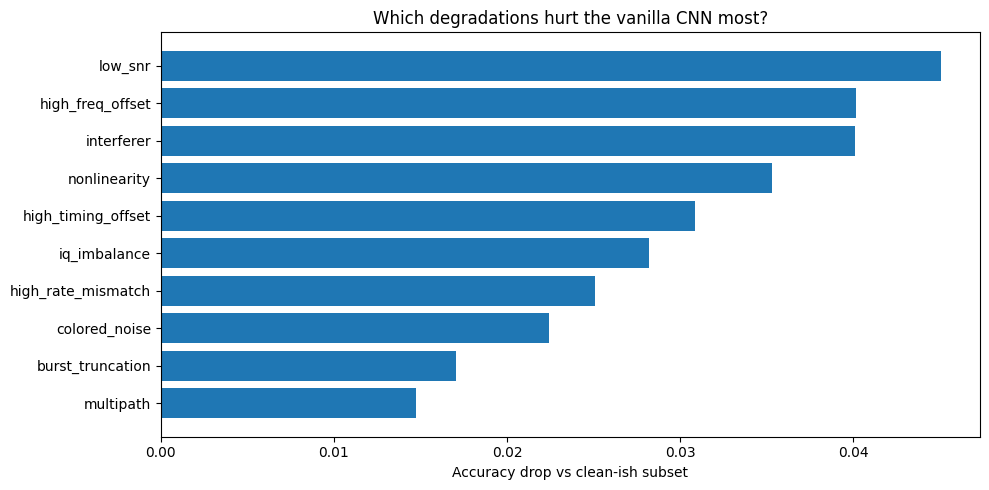

In [6]:
labels_plot = [row["subset"] for row in results if row["subset"] != "cleanish"]
drops_plot = [row["accuracy_drop_vs_cleanish"] for row in results if row["subset"] != "cleanish"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(labels_plot, drops_plot)
ax.invert_yaxis()
ax.set_xlabel("Accuracy drop vs clean-ish subset")
ax.set_title("Which degradations hurt the vanilla CNN most?")
plt.tight_layout()

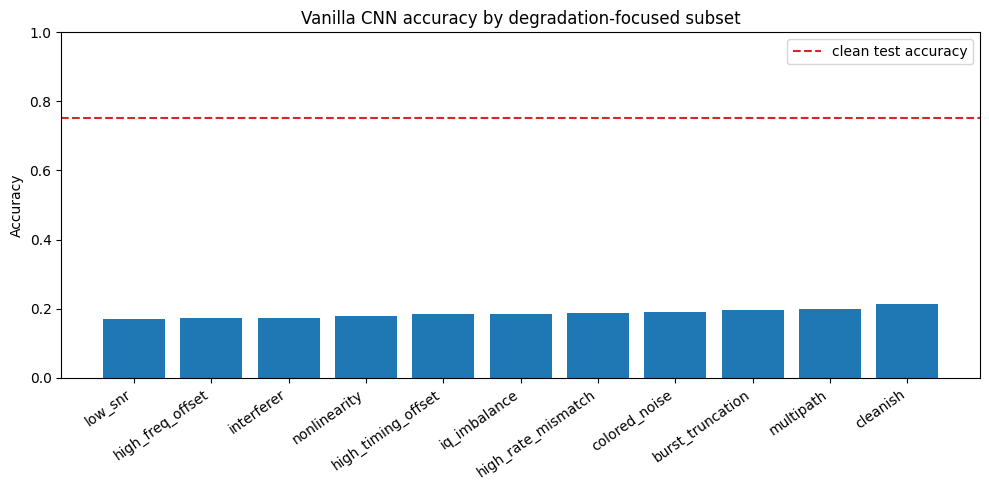

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
subset_names = [row["subset"] for row in results]
subset_acc = [row["accuracy"] for row in results]
ax.bar(subset_names, subset_acc)
ax.axhline(clean_result["test_acc"], color="tab:red", linestyle="--", label="clean test accuracy")
ax.set_ylim(0.0, 1.0)
ax.set_ylabel("Accuracy")
ax.set_title("Vanilla CNN accuracy by degradation-focused subset")
ax.legend()
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

## Interpretation

Use the ranking by `accuracy_drop_vs_cleanish` as the first-pass sensitivity measure. The top items are the degradations that most strongly break a vanilla CNN trained on clean synthetic IQ. If the most damaging factors are the same ones you expect in real SDR captures, those are the best candidates for either stronger augmentation or explicit architectural bias in the next round.